# Set Up


In [70]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import plotly.graph_objects as go

In [71]:
TECHNIQUE_MAPPING = {
    "Attack_on_Reputation": ['Name_Calling-Labeling', 'Guilt_by_Association', 'Doubt', 'Appeal_to_Hypocrisy', 'Questioning_the_Reputation'],
    "Justification": ['Flag_Waving', 'Appeal_to_Authority', 'Appeal_to_Popularity', 'Appeal_to_Fear-Prejudice', 'Appeal_to_Values'],
    "Distraction": ['Straw_Man', 'Red_Herring', 'Whataboutism', 'Appeal_to_Pity'],
    "Simplification": ['Causal_Oversimplification', 'False_Dilemma-No_Choice', 'False_Equivalence', 'Consequential_Oversimplification'],
    "Call": ['Slogans', 'Conversation_Killer', 'Appeal_to_Time'],
    "Manipulative_Wording": ['Loaded_Language', 'Obfuscation-Vagueness-Confusion', 'Exaggeration-Minimisation', 'Repetition']
}


# Load docs

Use your path. Those files are just our annotation tables as csv

In [74]:
df_topics_ru=pd.read_csv('/content/drive/MyDrive/LREC/topics_document_level_RU.csv')
df_topics_pl=pd.read_csv('/content/drive/MyDrive/LREC/topics_document_level_PL.csv')
df_topics_bg=pd.read_csv('/content/drive/MyDrive/LREC/topics_document_level_BG.csv')

Get our data on PTS back together

In [75]:
def merge_to_one(path):
  train_df = pd.read_csv(os.path.join(path, "train.csv"))
  test_df = pd.read_csv(os.path.join(path, "test.csv"))
  valid_df = pd.read_csv(os.path.join(path, "valid.csv"))
  merged_df = pd.concat([train_df, test_df, valid_df], ignore_index=True)
  merged_df.to_csv(os.path.join(path, "merged.csv"), index=False)

  return merged_df

In [76]:
df_ru=merge_to_one('/content/drive/MyDrive/LREC/data/RU')
df_pl=merge_to_one('/content/drive/MyDrive/LREC/data/PL')
df_bg=merge_to_one('/content/drive/MyDrive/LREC/data/BG')

Prepare topcs to merge with main data

In [77]:
def prepare_topics(df):
    df['ID'] = df['ID'].apply(lambda x: x if x.endswith('.txt') else x + '.txt')
    df = df[['ID', 'topic']]
    return df

In [78]:
df_topics_pl=prepare_topics(df_topics_pl)
df_pl = pd.merge(df_pl, df_topics_pl, left_on='filename', right_on='ID')


In [79]:
df_topics_ru=prepare_topics(df_topics_ru)
df_ru = pd.merge(df_ru, df_topics_ru, left_on='filename', right_on='ID')


In [80]:
df_topics_bg=prepare_topics(df_topics_bg)
df_bg = pd.merge(df_bg, df_topics_bg, left_on='filename', right_on='ID')

In [83]:
df_ru

,filename,start,end,content,techniques,persuasion_strategies,Attack_on_Reputation,Justification,Distraction,Simplification,Call,Manipulative_Wording,ID,topic
0,RU_Trump_2.txt,971,1069,А американцы не могут уважать соевого небинарн...,['Loaded_Language'],['Manipulative_Wording'],False,False,False,False,False,True,RU_Trump_2.txt,URW
1,RU_demography_5.txt,117,207,"Маткапитал выдаётся на первого ребёнка, о чём ...",['Loaded_Language'],['Manipulative_Wording'],False,False,False,False,False,True,RU_demography_5.txt,Demographic
2,RU_discrediting_the_west_10.txt,1175,1230,Есть план по набору контрактников и его надо в...,[],[],False,False,False,False,False,False,RU_discrediting_the_west_10.txt,URW
3,RU_discrediting_the_west_8.txt,844,926,"В последнее время, в последнюю неделю, наверно...",[],[],False,False,False,False,False,False,RU_discrediting_the_west_8.txt,URW
4,RU_1086.txt,911,1008,Об этом сообщил газете Il Giornale на условиях...,['Straw_Man'],['Distraction'],False,False,True,False,False,False,RU_1086.txt,URW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069,RU_URW_12.txt,1446,1535,"Тем более, что войск БРИКС потребуется много, ...",['Consequential_Oversimplification'],['Simplification'],False,False,False,True,False,False,RU_URW_12.txt,URW
2070,RU_1090.txt,2614,2698,Счета за электричество в ЕС уже в 3 раза дорож...,[],[],False,False,False,False,False,False,RU_1090.txt,URW
2071,RU_URW_7.txt,2039,2067,Во имя наших детей и внуков.,['Slogans'],['Call'],False,False,False,False,True,False,RU_URW_7.txt,URW
2072,RU_URW_6.txt,2120,2280,"Как говорится, если вам мешают памятники, назв...",['Whataboutism'],['Distraction'],False,False,True,False,False,False,RU_URW_6.txt,URW


# Co-occurance heatmap

In [84]:
def convert_to_lists(df):

    df['techniques'] = df['techniques'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df['persuasion_strategies'] = df['persuasion_strategies'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df['topic'] = df['topic'].apply(lambda x: [t.strip() for t in x.split(', ')] if isinstance(x, str) else x)
    df['topic'] = df['topic'].apply(lambda lst: [s.strip() for s in lst])

    return df


In [85]:
df_pl=convert_to_lists(df_pl)
df_ru=convert_to_lists(df_ru)
df_bg=convert_to_lists(df_bg)

In [88]:
df_bg

,filename,start,end,content,techniques,persuasion_strategies,Attack_on_Reputation,Justification,Distraction,Simplification,Call,Manipulative_Wording,ID,topic
0,trail_raw_BG_13.txt,4712,4835,"След което излязоха и другите медии, а българо...",[Name_Calling-Labeling],[Attack_on_Reputation],True,False,False,False,False,False,trail_raw_BG_13.txt,[Other]
1,20240704_URW_BG_26.txt,1349,1362,Благодаря Ви.,[],[],False,False,False,False,False,False,20240704_URW_BG_26.txt,"[URW, Defense]"
2,20240327_EUZ_BG_96.txt,3575,3757,Разглеждаме като много висок риск от политичес...,[Doubt],[Attack_on_Reputation],True,False,False,False,False,False,20240327_EUZ_BG_96.txt,[EU]
3,20240329_URW_BG_80.txt,3081,3417,Така беше освободена пазарна ниша за конкуренц...,[Causal_Oversimplification],[Simplification],False,False,False,True,False,False,20240329_URW_BG_80.txt,[URW]
4,20240329_URW_BG_80.txt,5203,5279,Точно поради тази причина в момента има три пъ...,[],[],False,False,False,False,False,False,20240329_URW_BG_80.txt,[URW]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4918,20240807_EUZ_BG_48.txt,459,607,Един от показателите за добре проведена полити...,[],[],False,False,False,False,False,False,20240807_EUZ_BG_48.txt,[EU]
4919,20240430_EUZ_BG_39.txt,65,129,"Господин Ганев, имате думата, след което е гос...",[],[],False,False,False,False,False,False,20240430_EUZ_BG_39.txt,[EU]
4920,20240228_URW_BG_86.txt,3298,3355,"ПРЕДСЕДАТЕЛ РОСЕН ЖЕЛЯЗКОВ: Лично обяснение, з...",[],[],False,False,False,False,False,False,20240228_URW_BG_86.txt,[URW]
4921,20240229_URW_BG_68.txt,2146,2369,"Това, което ясно трябва да се каже, е, че този...",[],[],False,False,False,False,False,False,20240229_URW_BG_68.txt,[URW]


## Simple heatmap with abs. values

In [93]:
def heatmap_data_topics(df, column, title):

    # Explode both lists so that each (topic, label) combination gets its own row
    df_exploded = df.explode('topic').explode(column)

    # Create co-occurrence table
    heatmap_data = pd.crosstab(df_exploded[column], df_exploded['topic'])

    # Plot heatmap

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='Blues', fmt='d')
    plt.title(f"Label–Topic Co-occurrence Heatmap for {title}")
    plt.ylabel("Topic")
    plt.xlabel(column)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

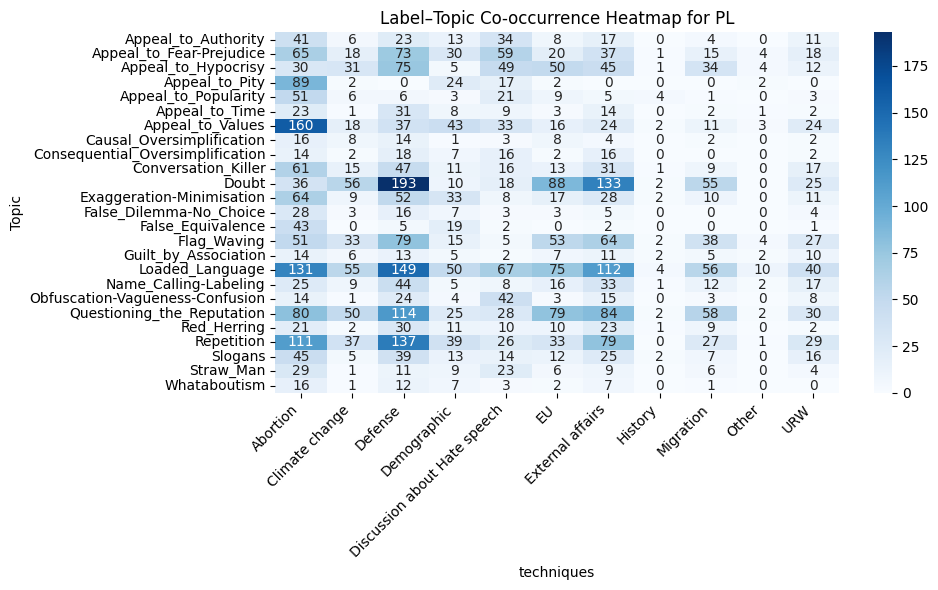

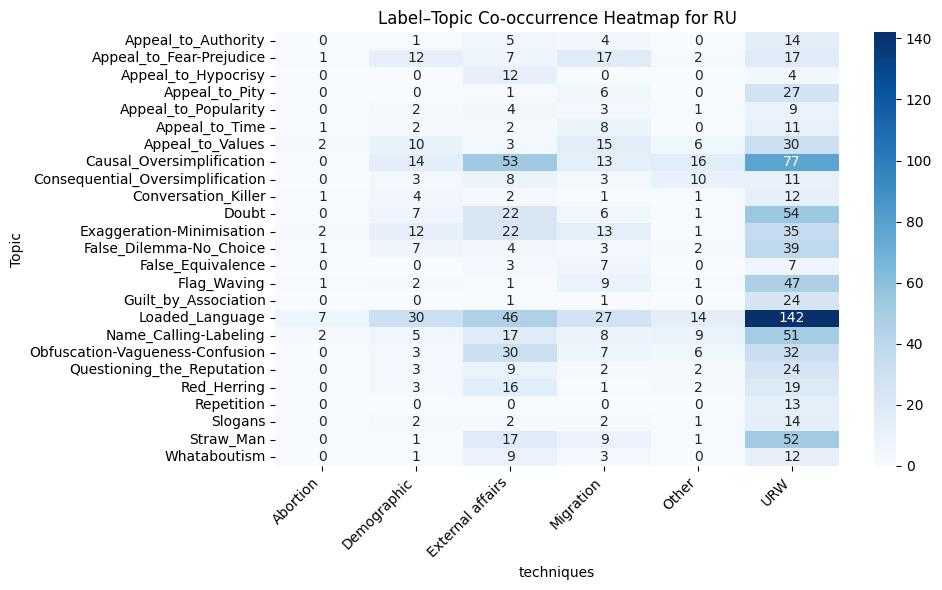

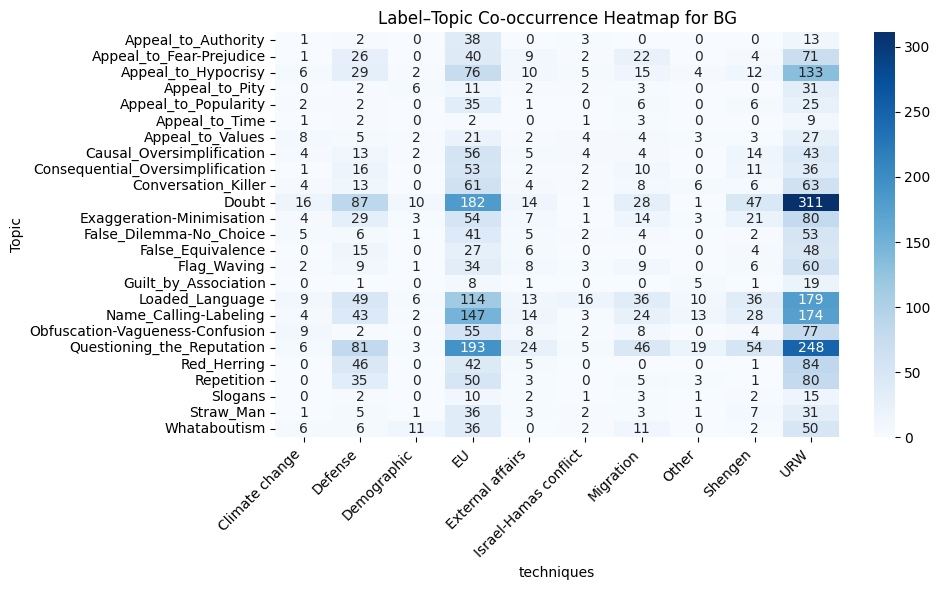

In [94]:
heatmap_data_topics(df_pl, 'techniques', 'PL')
heatmap_data_topics(df_ru, 'techniques', 'RU')
heatmap_data_topics(df_bg, 'techniques', 'BG')


Merge all languges together:

In [100]:
df_all = pd.concat([df_ru, df_pl, df_bg], ignore_index=True)


## Heatmap gruoped by the Stategies

In [95]:
def heatmap_gruped_by_stratigies(df, title):

    df["topic"] = df["topic"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df["techniques"] = df["techniques"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    df = df.explode("topic").explode("techniques")
    df = df[df["topic"].str.lower() != "other"]


    # Reverse mapping
    tech_to_strat = {tech: strat for strat, techs in TECHNIQUE_MAPPING.items() for tech in techs}
    df["strategy"] = df["techniques"].map(tech_to_strat)

    # --- Compute relative frequencies ---
    counts = df.groupby(["topic", "techniques"]).size().reset_index(name="count")
    topic_totals = counts.groupby("topic")["count"].transform("sum")
    counts["percent"] = counts["count"] / topic_totals * 100
    heatmap_df = counts.pivot(index="techniques", columns="topic", values="percent").fillna(0)

    # --- Order techniques by strategy ---
    tech_order = []
    strategy_sections = []
    for strat, techs in TECHNIQUE_MAPPING.items():
        group_techs = [t for t in techs if t in heatmap_df.index]
        if group_techs:
            tech_order.extend(group_techs)
            strategy_sections.append((strat, len(group_techs)))

    heatmap_df = heatmap_df.loc[tech_order]

    # --- Colors for each strategy ---
    colors = list(mcolors.TABLEAU_COLORS.values())
    strategy_colors = {strat: colors[i % len(colors)] for i, (strat, _) in enumerate(strategy_sections)}
    tech_colors = {tech: strategy_colors[tech_to_strat[tech]] for tech in tech_to_strat if tech in heatmap_df.index}

    # --- Plot heatmap ---
    plt.figure(figsize=(15, 10))
    ax = sns.heatmap(heatmap_df, cmap="YlGnBu", linewidths=0.3,annot=True, cbar_kws={"label": "Percentage within Topic"})

    # --- Colored bands for strategy grouping ---
    y_start = 0
    for strat, count in strategy_sections:
        color = strategy_colors[strat]
        y_center = y_start + count / 2
        ax.text(-3.5, y_center, strat, va='center', ha='right', rotation=90,  # moved further left
                fontsize=9, fontweight='bold', color=color)
        y_start += count
          # --- add horizontal divider line after each strategy ---
        ax.hlines(y_start, *ax.get_xlim(), colors='black', linewidth=1)


    # --- Color each technique label by its strategy ---
    y_labels = ax.get_yticklabels()
    for label in y_labels:
        tech = label.get_text()
        if tech in tech_colors:
            label.set_color(tech_colors[tech])
            label.set_fontweight("bold")

    ax.set_yticklabels(y_labels)

    # --- Final styling ---
    plt.title(f"Label–Topic Co-occurrence Heatmap Grouped by Strategies for {title}", fontsize=13)
    plt.ylabel("")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()


For BG:

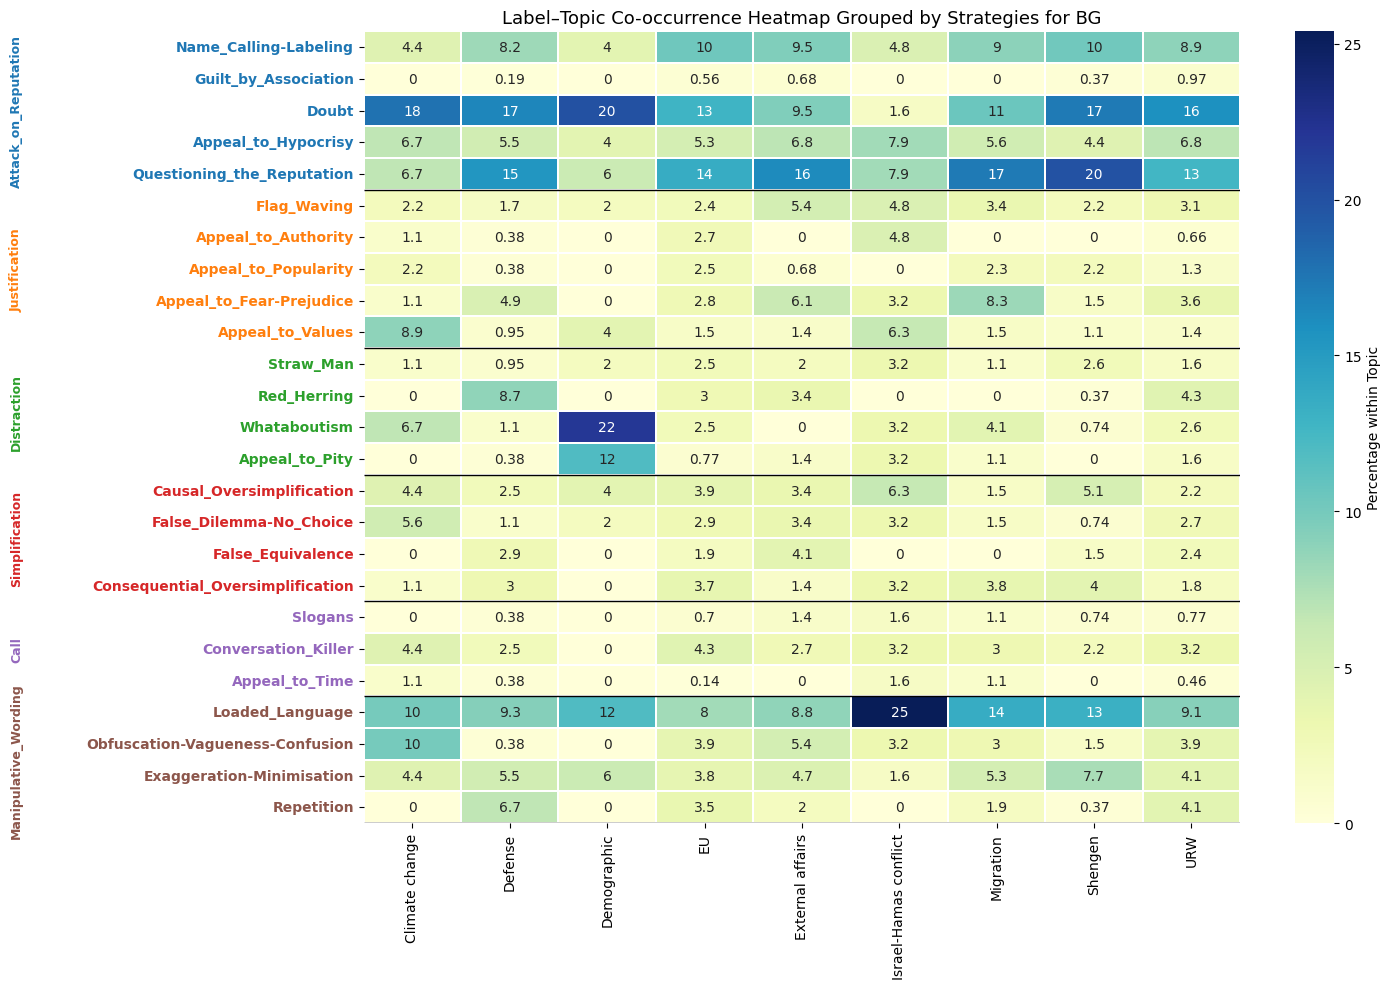

In [96]:
heatmap_gruped_by_stratigies(df_bg, 'BG' )

For RU

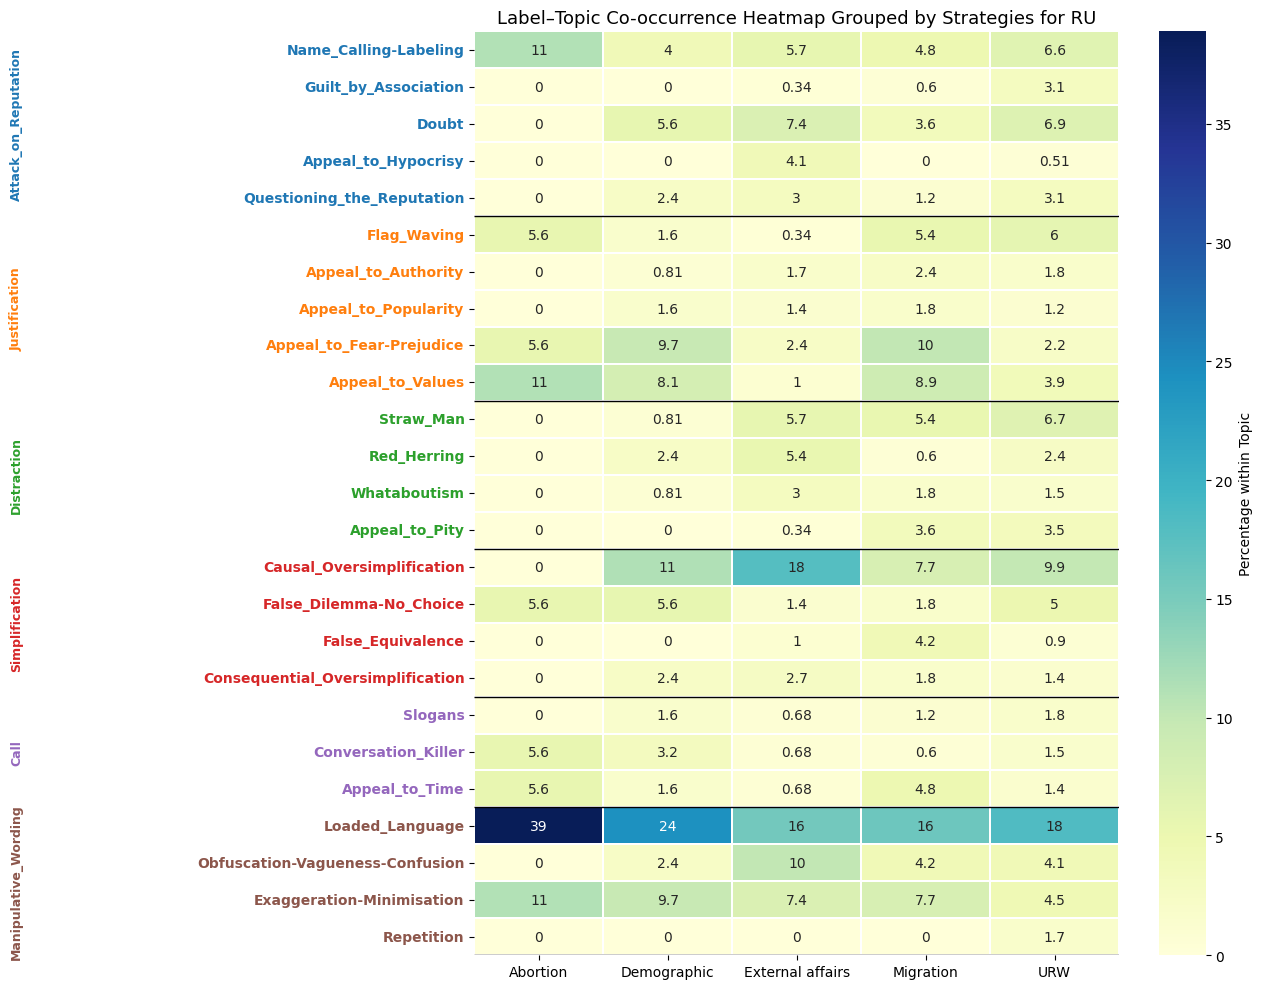

In [97]:
heatmap_gruped_by_stratigies(df_ru, 'RU')

For PL

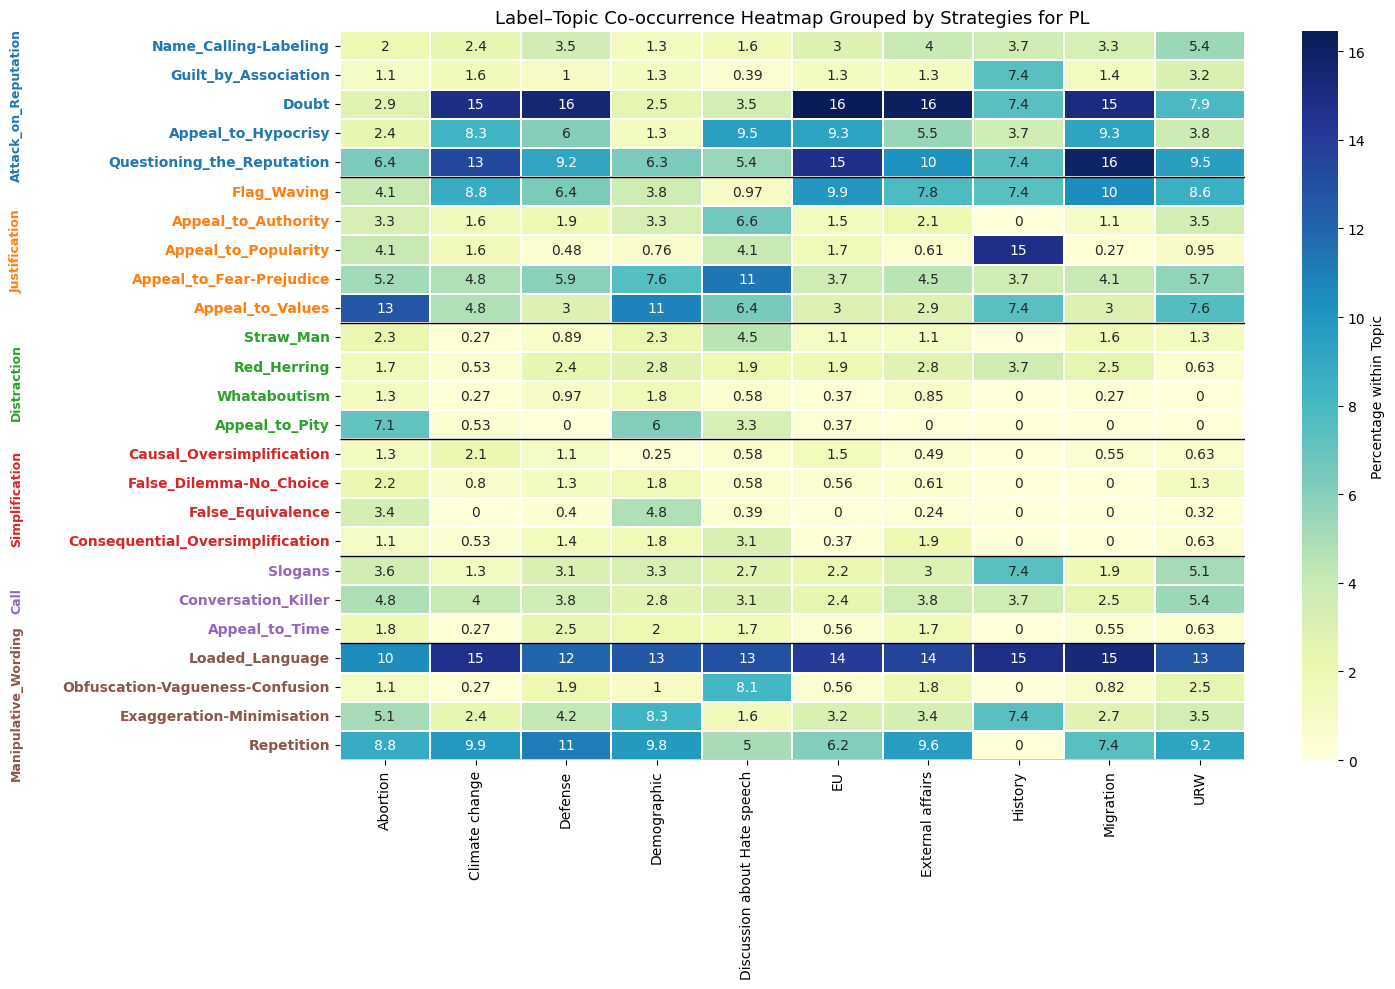

In [98]:
heatmap_gruped_by_stratigies(df_pl, 'PL')

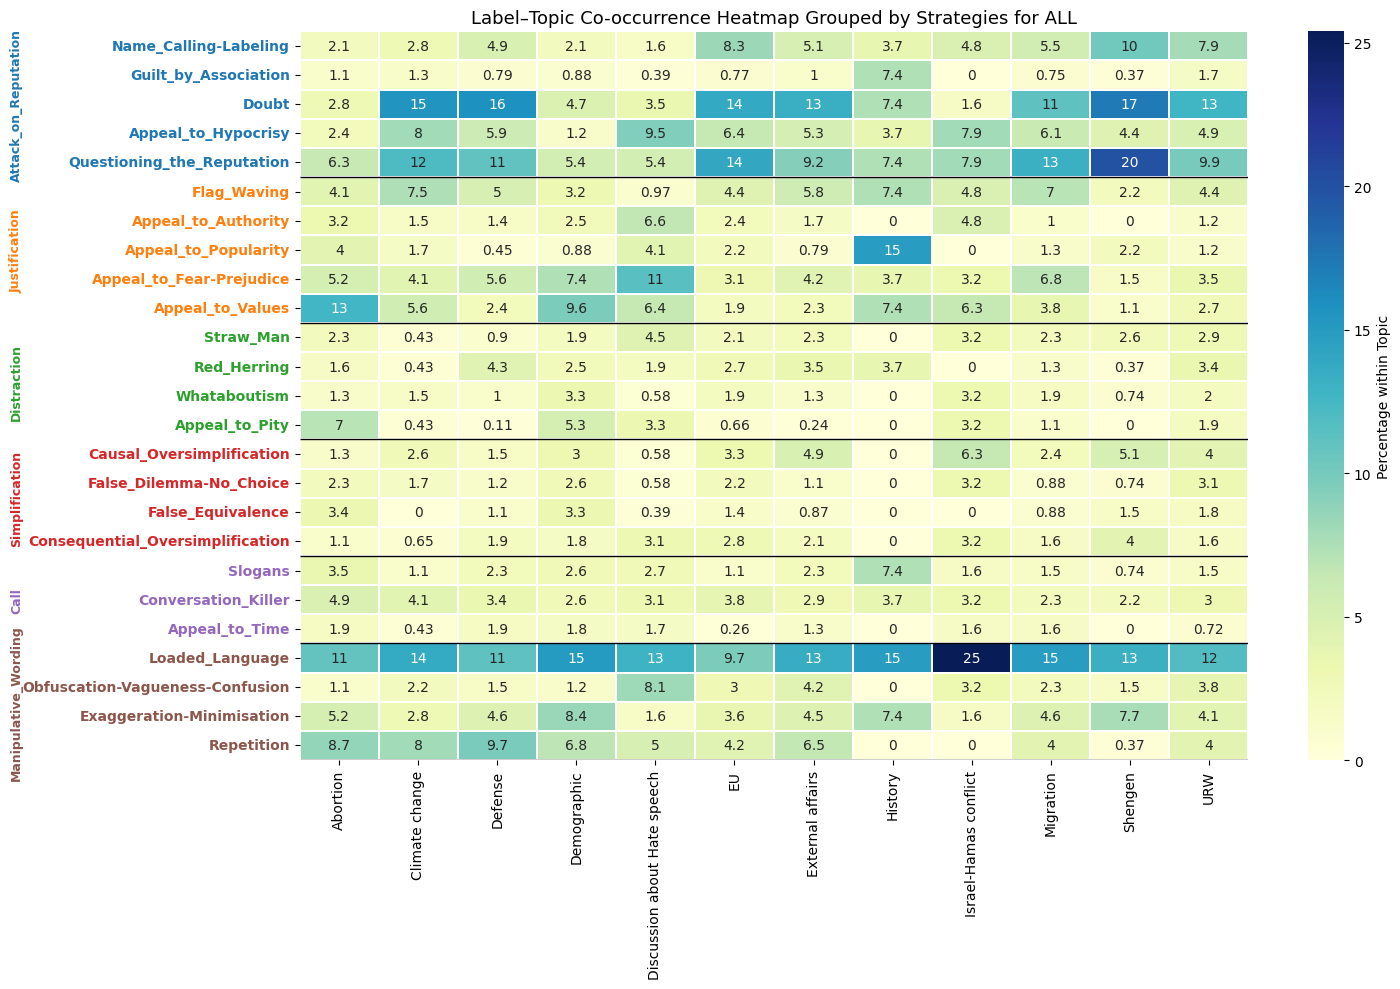

In [101]:
heatmap_gruped_by_stratigies(df_all, 'ALL')


## Sankey

In [102]:
def sankey_plot_color(df, title):
    # --- Load data ---
    df["topic"] = df["topic"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df["techniques"] = df["techniques"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df = df.explode("topic").explode("techniques")

    # 🔽 Exclude "other" topics
    df = df[df["topic"].str.lower() != "other"]

    # Reverse mapping
    tech_to_strat = {tech: strat for strat, techs in TECHNIQUE_MAPPING.items() for tech in techs}
    df["strategy"] = df["techniques"].map(tech_to_strat)

    # --- Aggregate counts ---
    counts = df.groupby(["topic", "strategy"]).size().reset_index(name="count")

    # --- Build node lists ---
    topics = list(counts["topic"].unique())
    strategies = list(counts["strategy"].unique())
    nodes = topics + strategies

    # Assign node indices
    node_indices = {name: i for i, name in enumerate(nodes)}

    # --- Define color mapping for strategies ---
    strategy_colors = {
        "Attack_on_Reputation": "#1f78b3",
        "Manipulative_Wording": "#00a210",
        "Justification": "#f40008",
        "Simplification": "#ff7300",
        "Call": "#693d9a",
        "Distraction": "#b15928"
    }

    # Color nodes: topics = gray, strategies = their color
    node_colors = []
    for n in nodes:
        if n in topics:
            node_colors.append("lightgray")
        else:
            strat = n
            node_colors.append(strategy_colors.get(strat, "gray"))

    # --- Build links ---
    source = [node_indices[row["topic"]] for _, row in counts.iterrows()]
    target = [node_indices[row["strategy"]] for _, row in counts.iterrows()]
    value = [row["count"] for _, row in counts.iterrows()]

    link_colors = [strategy_colors[row["strategy"]] for _, row in counts.iterrows()]

    # --- Create Sankey diagram ---
    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=nodes,
            color=node_colors
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_colors
        )
    )])

    fig.update_layout(
        title_text=f"Flow of Manipulative Strategies Across Topics for {title}",
        font=dict(size=12),
        plot_bgcolor="white",
        paper_bgcolor="white",
        height=800,
        width=1100
    )

    fig.show()

In [104]:
sankey_plot_color(df_ru, 'RU')

In [105]:
sankey_plot_color(df_pl, 'PL')

In [106]:
sankey_plot_color(df_bg,'BG')

In [107]:
sankey_plot_color(df_all, 'all')

# Ongoing experiment
Clustering of the techniques depending on topic

In [108]:
import pandas as pd
import ast
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

def umap_plot(df): # Renamed function to avoid conflict with library name
    # --- Load and preprocess ---
    df["topic"] = df["topic"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df["techniques"] = df["techniques"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df = df.explode("topic").explode("techniques")

    # 🔽 Exclude "other" topics
    df = df[df["topic"].str.lower() != "other"]

    # Reverse mapping
    tech_to_strat = {tech: strat for strat, techs in TECHNIQUE_MAPPING.items() for tech in techs}
    df["strategy"] = df["techniques"].map(tech_to_strat)

    # --- Create topic–strategy frequency matrix ---
    counts = df.groupby(["topic", "techniques"]).size().reset_index(name="count")
    matrix = counts.pivot(index="techniques", columns="topic", values="count").fillna(0)

    # Normalize by topic (relative frequencies)
    matrix_norm = normalize(matrix, norm="l1", axis=1)  # rows sum to 1
    matrix_norm = pd.DataFrame(matrix_norm, index=matrix.index, columns=matrix.columns)

    # --- Apply UMAP ---
    reducer = umap.UMAP(random_state=42, n_neighbors=5, min_dist=0.3)
    embedding = reducer.fit_transform(matrix_norm)

    # --- Plot ---
    plt.figure(figsize=(8, 6))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=100, alpha=0.8)

    for i, topic in enumerate(matrix.index):
        plt.text(embedding[i, 0], embedding[i, 1], topic, fontsize=9, ha='center', va='center')

    plt.title("UMAP Projection: Tecniques similarities by Topics")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



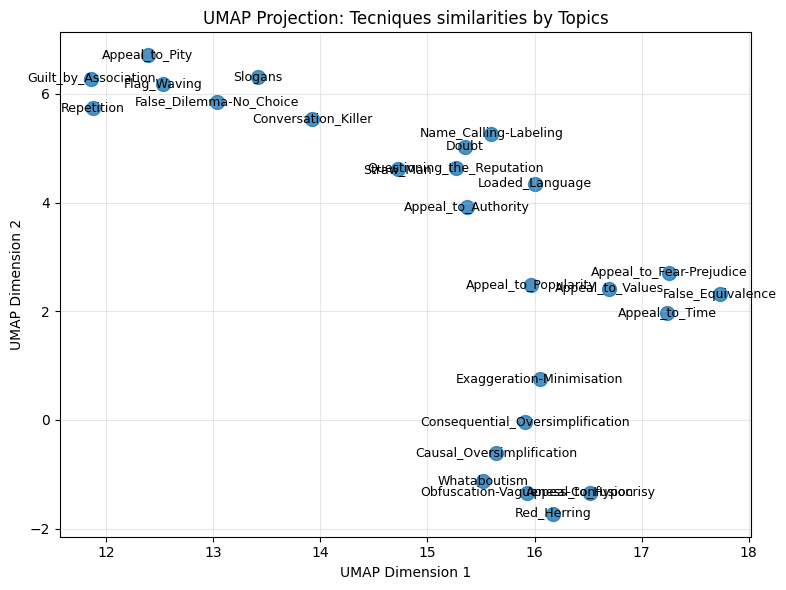

In [109]:
umap_plot(df_ru)